Dong Woon Kim, M.D.  
BRUIN ID: 21399491  

Bellevue University  
Masters in Data Science  
DSC 550 Data Mining

## Term Project Milestone 1

**Problem**:

The World Health Organization (WHO) published a statement that implored the use of the best available scientific or research evidence even over a physician's own opinion gained through their clinical experience to implement clinical decisions to improve patient outcomes[^1]. The Oxford Centre for Evidence-Based Medicine (CEBM) has stated that systematic reviews of randomized controlled trials are the best available evidence [^1],[^2]. 

Despite the importance systematic reviews and meta-analyses are supposed to play in the field of medicine, there is a lack of consistency and quality in these types of studies available for physicians in the literature databases, exacerbated by the inefficiency by which they are completed, with the average time for completing and publishing systematic reviews from start to finish for research teams being 11.5 months and 16.2 months, respectively[^3]. Currently, most teams are still performing systematic reviews manually, with excel spreadsheets and printed full-text PDFs. 

| category   |   mean |    sd |   median |   iqr |   min |    max |
|:-----------|-------:|------:|---------:|------:|------:|-------:|
| authors    |   5    |  3    |     5    |   3   |     1 |  27    |
| time       |  67.3  | 31    |    65.8  |  41.6 |     6 | 186    |
| yield      |   2.94 |  6.49 |     0.93 |   2.5 |     0 |  64.71 |

![fig_1a](./figures/fig_1a.png)
![fig_1b](./figures/fig_1b.png)


| category   |   time |   authors |
|:-----------|-------:|----------:|
| funded     |     42 |       6.8 |
| not funded |     26 |       4.8 |

![fig_2|30](./figures/fig_2.png)


On the other hand, research teams and software companies have developed automation tools to shorten the amount of time it takes to complete these systematic review papers. In fact, one team has published an award-winning article that outlines how a systematic review paper was and can be completed in 2 weeks. However, the software and tools they used are largely inaccessible to the average researcher, produce inconsistent and inaccurate results. Furthermore, much of these automation tools rely on artificial intelligence, which do not have the intuition and sense that is required to bridge the evidence together with a practical solution to be applied. Research is filling in gaps of knowledge with new data, while artificial intelligence is designed to summarize what has already been filled with old data. 

| task                         |   hours |
|:-----------------------------|--------:|
| find previous or upcoming SR |      63 |
| deduplication                |      16 |
| protocol                     |     175 |
| search strategy              |     109 |
| search                       |      72 |
| title abstract screening     |     404 |
| pdf                          |      41 |
| full-text screening          |     187 |
| trial registries screening   |     123 |
| citation screening           |     201 |
| forms                        |      72 |
| extraction                   |     461 |
| risk of bias                 |     323 |
| meta-analysis                |     167 |
| manuscript                   |     428 |

Therefore, I wanted to find a solution that meets these two somewhere in the middle. A ***system*** for conducting ***systematic*** reviews, where the user inputs dictate every nuance of automation, which does not rely on third party or artificial intelligence. 

![fig_3](./figures/fig_3.png)

<!--- 
If someone wants to know if drinking milk really does make your bones stronger or not, then they should be able to find not only the best source of evidence, but all of it at once, which is combined into one dataset that is summarized in a forest plot that clearly shows the statistical analysis results not only numerically but also in a visually-appealing and informative way.
-->

**Code used to generate tables and figures**:

**Table 1**

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df1 = pd.DataFrame({
    "category": ["funded", "not funded"],
    "time": [42, 26],
    "authors": [6.8, 4.8]})

In [6]:
df1.head()

,category,time,authors
0,funded,42,6.8
1,not funded,26,4.8


**Figure 1**

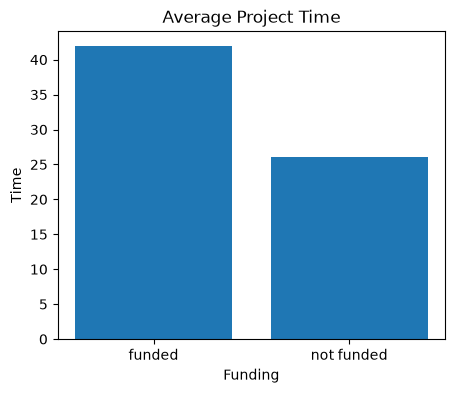

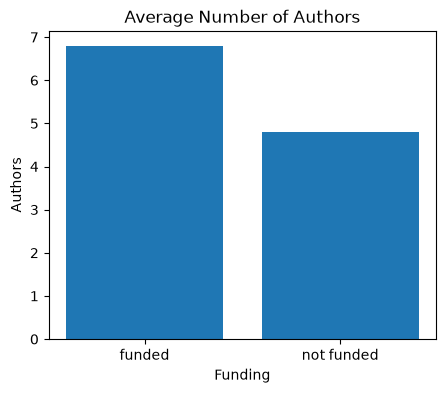

In [26]:
plt.figure(figsize=(5,4))

plt.bar(df1["category"], df1["time"])

plt.ylabel("Time")
plt.xlabel("Funding")
plt.title("Average Project Time")
plt.savefig("./Exercises/figures/fig_1a.png", dpi=300)
plt.show()

plt.figure(figsize=(5,4))

plt.bar(df1["category"], df1["authors"])

plt.ylabel("Authors")
plt.xlabel("Funding")
plt.title("Average Number of Authors")
plt.savefig("./Exercises/figures/fig_1b.png", dpi=300, bbox_inches="tight")
plt.show()

**Table 2**

In [8]:
df2 = pd.DataFrame(np.array([
        ["authors", 5, 3, 5, 3, 1, 27],
        ["time", 67.3, 31, 65.8, 41.6, 6, 186],
        ["yield", 2.94, 6.49, 0.93, 2.5, 0, 64.71]]),
        columns = ["category", "mean", "sd", "median", "iqr", "min", "max"]
)

In [29]:
df2.head()
from IPython.display import display, Markdown, HTML
display(Markdown(df2.to_markdown(index = False)))

print(df1.to_markdown(index = False))

| category   |   mean |    sd |   median |   iqr |   min |    max |
|:-----------|-------:|------:|---------:|------:|------:|-------:|
| authors    |   5    |  3    |     5    |   3   |     1 |  27    |
| time       |  67.3  | 31    |    65.8  |  41.6 |     6 | 186    |
| yield      |   2.94 |  6.49 |     0.93 |   2.5 |     0 |  64.71 |

| category   |   time |   authors |
|:-----------|-------:|----------:|
| funded     |     42 |       6.8 |
| not funded |     26 |       4.8 |


**Figure 2**

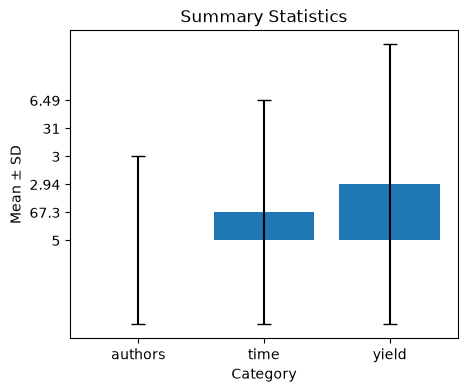

In [28]:
plt.figure(figsize=(5,4))

plt.bar(
    df2["category"],
    df2["mean"],
    yerr=df2["sd"],
    capsize=5
)

plt.ylabel("Mean ± SD")
plt.xlabel("Category")
plt.title("Summary Statistics")
plt.savefig("./Exercises/figures/fig_2.png", dpi=300)
plt.show()

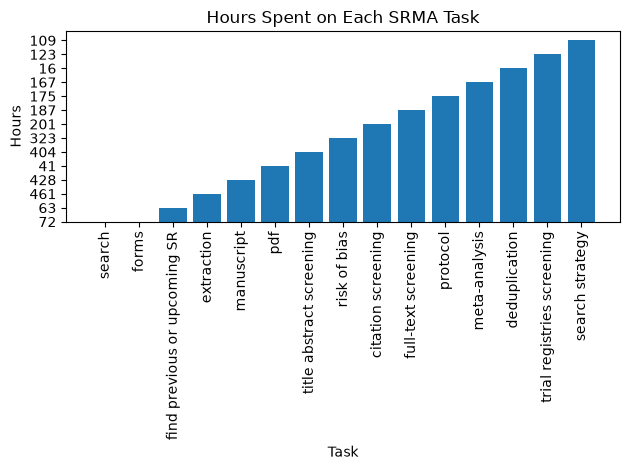

In [30]:
df3 = pd.DataFrame(np.array([
        ["find previous or upcoming SR", 63],
        ["deduplication", 16],
        ["protocol", 175],
        ["search strategy", 109],
        ["search", 72],
        ["title abstract screening", 404],
        ["pdf", 41],
        ["full-text screening", 187],
        ["trial registries screening", 123],
        ["citation screening", 201],
        ["forms", 72],
        ["extraction", 461],
        ["risk of bias", 323],
        ["meta-analysis", 167],
        ["manuscript", 428]]),
        columns = ["task", "hours"])

df3_sorted = df3.sort_values("hours", ascending=False)

plt.bar(df3_sorted["task"], df3_sorted["hours"])

plt.xticks(rotation=90)
plt.ylabel("Hours")
plt.xlabel("Task")
plt.title("Hours Spent on Each SRMA Task")

plt.tight_layout()
plt.savefig("./Exercises/figures/fig_3.png", dpi=300)
plt.show()

In [16]:
df3.head(15)
print(df3.to_markdown(index = False))

| task                         |   hours |
|:-----------------------------|--------:|
| find previous or upcoming SR |      63 |
| deduplication                |      16 |
| protocol                     |     175 |
| search strategy              |     109 |
| search                       |      72 |
| title abstract screening     |     404 |
| pdf                          |      41 |
| full-text screening          |     187 |
| trial registries screening   |     123 |
| citation screening           |     201 |
| forms                        |      72 |
| extraction                   |     461 |
| risk of bias                 |     323 |
| meta-analysis                |     167 |
| manuscript                   |     428 |


**References**

[^1]: https://www.who.int/publications/i/item/9789240039872  
[^2]: https://www.cebm.ox.ac.uk/resources/levels-of-evidence/oxford-centre-for-evidence-based-medicine-levels-of-evidence-march-2009  
[^3]: https://pmc.ncbi.nlm.nih.gov/articles/PMC12487012/  
[^4]: https://bmjopen.bmj.com/content/7/2/e012545#DC1    
[^5]: https://www.sciencedirect.com/science/article/zpii/S089543561930719X

[1] https://www.who.int/publications/i/item/9789240039872  
[2] https://www.cebm.ox.ac.uk/resources/levels-of-evidence/oxford-centre-for-evidence-based-medicine-levels-of-evidence-march-2009  
[3] https://pmc.ncbi.nlm.nih.gov/articles/PMC12487012/  
[4] https://bmjopen.bmj.com/content/7/2/e012545#DC1   
[5] https://www.sciencedirect.com/science/article/pii/S089543561930719X